# Punjab Onion Price — Data Pipeline

**Steps:**
1. Concatenate raw yearly CSVs  
2. Clean (drop NaNs, remove duplicates)  
3. Fuzzy-match mandi names → coordinates  
4. Spatial filter — keep only mandis inside Punjab  
5. Fetch ERA5 daily weather via CDS API  
6. Join ERA5 features to each mandi × date row  
7. Save final training dataset


## 1  Imports & setup

In [17]:
import os
import glob
import re

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from rapidfuzz import process, fuzz

# ERA5 / NetCDF
import cdsapi
import xarray as xr

print("All imports OK")


All imports OK


## 2  Paths

In [18]:
RAW_DIR        = "data/raw"
PROCESSED_DIR  = "data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Input files
RAW_CSV_GLOB   = os.path.join(RAW_DIR, "Punjab_Onion_*.csv")
COORD_CSV      = os.path.join(RAW_DIR, "Punjab_mandi_coordinates.csv")
SHAPEFILE      = os.path.join(RAW_DIR, "gadm41_IND_shp", "gadm41_IND_1.shp")
ERA5_NC        = os.path.join(PROCESSED_DIR, "era5_punjab.nc")

# Output files
OUT_CONCAT     = os.path.join(PROCESSED_DIR, "step1_concatenated.csv")
OUT_COORDS     = os.path.join(PROCESSED_DIR, "step2_with_coords.csv")
OUT_SPATIAL    = os.path.join(PROCESSED_DIR, "step3_punjab_only.csv")
OUT_FINAL      = os.path.join(PROCESSED_DIR, "final_training_dataset.csv")


## 3  Concatenate yearly CSVs & basic cleaning

In [19]:
files = sorted(glob.glob(RAW_CSV_GLOB))
print(f"Found {len(files)} files:")
for f in files:
    print(" ", f)

frames = []
for f in files:
    tmp = pd.read_csv(f)
    frames.append(tmp)

df = pd.concat(frames, ignore_index=True)
print(f"\nTotal rows after concat: {len(df)}")

# ── parse date
df["t"] = pd.to_datetime(df["t"], errors="coerce")

# ── drop rows where price or date is missing
df = df.dropna(subset=["t", "p_modal"])

# ── drop exact duplicates (same date + same market_id)
before = len(df)
df = df.drop_duplicates(subset=["t", "market_id", "variety"], keep="last")
print(f"Dropped {before - len(df)} duplicate rows  →  {len(df)} rows remain")

# ── sort
df = df.sort_values(["t", "market_name"]).reset_index(drop=True)

# ── keep only useful columns
KEEP = ["t", "market_id", "market_name", "district_name",
        "variety", "p_min", "p_max", "p_modal"]
df = df[KEEP]

df.to_csv(OUT_CONCAT, index=False)
print(f"\nSaved → {OUT_CONCAT}")
df.head()


Found 8 files:
  data/raw\Punjab_Onion_17_18.csv
  data/raw\Punjab_Onion_18_19.csv
  data/raw\Punjab_Onion_19_20.csv
  data/raw\Punjab_Onion_20_21.csv
  data/raw\Punjab_Onion_21_22.csv
  data/raw\Punjab_Onion_22_23.csv
  data/raw\Punjab_Onion_23_24.csv
  data/raw\Punjab_Onion_24_25.csv

Total rows after concat: 8000
Dropped 0 duplicate rows  →  8000 rows remain

Saved → data/processed\step1_concatenated.csv


,t,market_id,market_name,district_name,variety,p_min,p_max,p_modal
0,2017-12-11,623,Ajnala,Amritsar,Red,2000.0,2400.0,2200
1,2017-12-11,239,Baghapurana,Moga,Other,3500.0,4000.0,3800
2,2017-12-11,4439,Banur (Kheragaju),Sahibzada Ajit Singh Nagar,1st Sort,3000.0,4000.0,3200
3,2017-12-11,1574,Bhucho,Bathinda,Other,2500.0,3200.0,3000
4,2017-12-11,1611,Chamkaur Sahib,Rupnagar,Other,4000.0,4200.0,4100


## 4  Fuzzy-match mandi names → coordinates

In [20]:
coord_df = pd.read_csv(COORD_CSV)
print(f"Coordinate records: {len(coord_df)}")
coord_df.head()


Coordinate records: 153


,mandi,latitude,longitude
0,ABOHAR,30.1550,74.1948
1,ADAMPUR,31.4254,75.7200
2,AHMEDGARH,30.6813,75.8269
3,AJITWAL,30.8124,75.3438
4,AJNALA,29.7941,76.9207


In [21]:
def clean_name(x):
    """Normalise a mandi name for fuzzy matching."""
    x = str(x).upper()
    x = re.sub(r'APMC|MANDI|MARKET', '', x)
    x = re.sub(r'[^A-Z0-9 ]', '', x)
    x = ' '.join(x.split())
    return x

df["clean_market"]      = df["market_name"].apply(clean_name)
coord_df["clean_mandi"] = coord_df["mandi"].apply(clean_name)

choices = coord_df["clean_mandi"].tolist()          # explicit list — no type issues
names   = df["clean_market"].tolist()               # same

SCORE_THRESHOLD = 75

matched_idx = []
scores      = []

for name in names:                                  # iterate over plain list
    result = process.extractOne(name, choices, scorer=fuzz.token_sort_ratio)
    if result and result[1] >= SCORE_THRESHOLD:
        matched_idx.append(result[2])
        scores.append(result[1])
    else:
        matched_idx.append(None)
        scores.append(None)

df["match_score"] = scores

def _get(col, idx):
    return coord_df.at[idx, col] if idx is not None else float("nan")

df["latitude"]  = [_get("latitude",  i) for i in matched_idx]
df["longitude"] = [_get("longitude", i) for i in matched_idx]

n_matched   = df["latitude"].notna().sum()
n_unmatched = df["latitude"].isna().sum()
print(f"Matched   : {n_matched}")
print(f"Unmatched : {n_unmatched}")

unmatched_names = df.loc[df["latitude"].isna(), "market_name"].unique()
print("\nUnmatched mandi names (review these):")
print(unmatched_names[:30])

df.to_csv(OUT_COORDS, index=False)
print(f"\nSaved → {OUT_COORDS}")


Matched   : 7037
Unmatched : 963

Unmatched mandi names (review these):
<StringArray>
[            'Banur (Kheragaju)',       'GarhShankar (Kotfatuhi)',
      'Rampuraphul(Nabha Mandi)',                   'Tanda Urmur',
        'Garh Shankar(Mahalpur)',     'Jalandhar City(Jalandhar)',
     'Nawan Shahar(Subzi Mandi)',                       'Sirhind',
                    'Lehra Gaga',             'Mukerian(Talwara)',
 'Amritsar(Amritsar Mewa Mandi)',                   'F.G.Churian',
                         'Bilga', 'Sri Har Gobindpur(Harechowal)',
                    'Noor Mehal']
Length: 15, dtype: str

Saved → data/processed\step2_with_coords.csv


## 5  Spatial filter — keep mandis inside Punjab

In [22]:
# drop rows with no coordinates before spatial join
df = pd.read_csv(OUT_COORDS)
df = df.dropna(subset=["latitude", "longitude"])
print(f"Rows with coordinates: {len(df)}")

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# load state boundaries, isolate Punjab
states = gpd.read_file(SHAPEFILE)
punjab = states[states["NAME_1"] == "Punjab"].to_crs("EPSG:4326")

# spatial join — inner keeps only points inside Punjab
filtered = gpd.sjoin(gdf, punjab[["geometry"]], predicate="within", how="inner")
filtered = filtered.drop(columns=["index_right"], errors="ignore")

print(f"Before spatial filter : {len(gdf)}")
print(f"After  spatial filter : {len(filtered)}")
print(f"Removed (outside PB)  : {len(gdf) - len(filtered)}")

# convert back to plain DataFrame (drop geometry col for CSV)
filtered_df = pd.DataFrame(filtered.drop(columns="geometry"))

filtered_df.to_csv(OUT_SPATIAL, index=False)
print(f"\nSaved → {OUT_SPATIAL}")
filtered_df.head()


Rows with coordinates: 7037
Before spatial filter : 7037
After  spatial filter : 6855
Removed (outside PB)  : 182

Saved → data/processed\step3_punjab_only.csv


,t,market_id,market_name,district_name,variety,p_min,p_max,p_modal,clean_market,match_score,latitude,longitude
1,2017-12-11,239,Baghapurana,Moga,Other,3500.0,4000.0,3800,BAGHAPURANA,95.652174,30.6815,75.0867
3,2017-12-11,1574,Bhucho,Bathinda,Other,2500.0,3200.0,3000,BHUCHO,100.000000,30.2109,75.0942
4,2017-12-11,1611,Chamkaur Sahib,Rupnagar,Other,4000.0,4200.0,4100,CHAMKAUR SAHIB,100.000000,30.8978,76.4040
5,2017-12-11,1751,Dera Bassi,Sahibzada Ajit Singh Nagar,Other,3500.0,3700.0,3600,DERA BASSI,100.000000,30.6815,75.0867
6,2017-12-11,248,Dhuri,Sangrur,Other,3500.0,3700.0,3600,DHURI,100.000000,30.3700,75.8700


## 5a  Quick sanity-check map

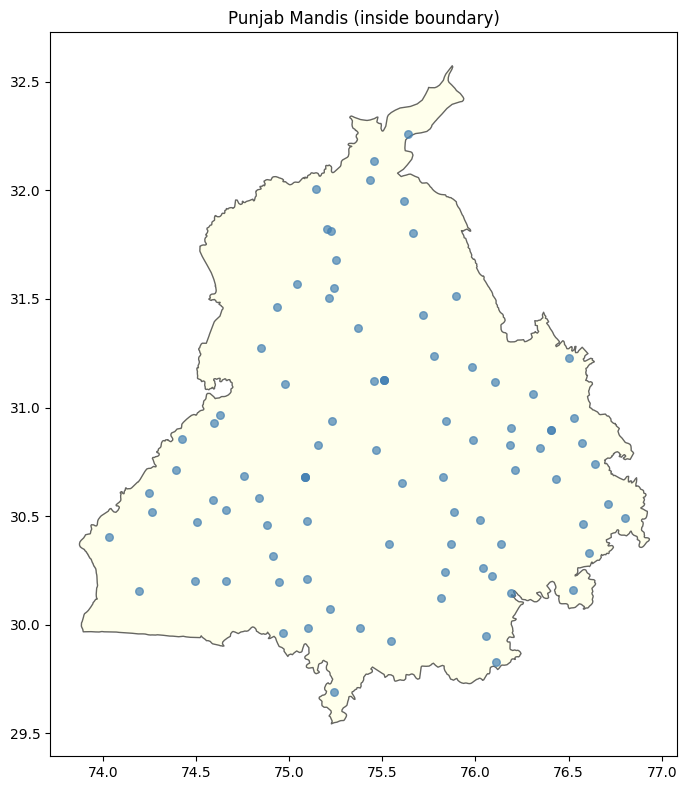

Unique mandis: 90


In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
punjab.plot(ax=ax, edgecolor="black", facecolor="lightyellow", alpha=0.6)

# unique mandi points only
pts = filtered_df[["market_name","latitude","longitude"]].drop_duplicates()
gpd.GeoDataFrame(
    pts,
    geometry=gpd.points_from_xy(pts["longitude"], pts["latitude"]),
    crs="EPSG:4326"
).plot(ax=ax, markersize=30, color="steelblue", alpha=0.7)

plt.title("Punjab Mandis (inside boundary)")
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "mandis_map.png"), dpi=150)
plt.show()
print(f"Unique mandis: {pts['market_name'].nunique()}")


## 6  Download ERA5-Land daily weather

**Before running this cell:**  
- Make sure `~/.cdsapirc` contains your CDS API key:
  ```
  url: https://cds.climate.copernicus.eu/api
  key: <your-key-here>
  ```
- The download covers **all years present in the price data** for the **Punjab bounding box** only.  
  This keeps the file small (~few GB). Expect 10-40 min per year.

Variables downloaded:
| Variable | ERA5 name |
|---|---|
| 2 m temperature | `2m_temperature` |
| 2 m dew-point temperature | `2m_dewpoint_temperature` |
| Total precipitation | `total_precipitation` |
| 10 m u-component of wind | `10m_u_component_of_wind` |
| 10 m v-component of wind | `10m_v_component_of_wind` |


In [24]:
# Punjab bounding box [North, West, South, East]
PB_BBOX = [32.5, 73.8, 29.5, 76.9]

ERA5_VARIABLES = [
    "2m_temperature",
    "2m_dewpoint_temperature",
    "total_precipitation",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
]

# Derive years from price data
df_price = pd.read_csv(OUT_SPATIAL)
df_price["t"] = pd.to_datetime(df_price["t"])
years = sorted(df_price["t"].dt.year.unique().tolist())
print("Years in price data:", years)

ERA5_DIR = os.path.join(PROCESSED_DIR, "era5_monthly")
os.makedirs(ERA5_DIR, exist_ok=True)

client = cdsapi.Client()

# ── Download one month at a time — smallest possible request ─────────────────
for year in years:
    for month in range(1, 13):
        fname = os.path.join(ERA5_DIR, f"era5_{year}_{month:02d}.nc")

        if os.path.exists(fname):
            print(f"  {year}-{month:02d} already exists — skip")
            continue

        print(f"  Downloading {year}-{month:02d} …", end=" ", flush=True)
        try:
            client.retrieve(
                "reanalysis-era5-land",
                {
                    "variable": ERA5_VARIABLES,
                    "year":  [str(year)],
                    "month": [f"{month:02d}"],
                    "day":   [f"{d:02d}" for d in range(1, 32)],
                    "time":  ["00:00", "06:00", "12:00", "18:00"],
                    "area":  PB_BBOX,
                    "data_format": "netcdf",
                    "download_format": "unarchived",
                },
                fname,
            )
            print("done")
        except Exception as e:
            print(f"FAILED: {e}")
            # remove partial file so it retries cleanly next run
            if os.path.exists(fname):
                os.remove(fname)

monthly_files = sorted(glob.glob(os.path.join(ERA5_DIR, "era5_*.nc")))
print(f"\nTotal monthly files on disk: {len(monthly_files)}")
print("Expected:", len(years) * 12)


Years in price data: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
  2017-01 already exists — skip
  2017-02 already exists — skip
  2017-03 already exists — skip
  2017-04 already exists — skip
  2017-05 already exists — skip
  2017-06 already exists — skip
  2017-07 already exists — skip
  2017-08 already exists — skip
  2017-09 already exists — skip
  2017-10 already exists — skip
  2017-11 already exists — skip
  2017-12 already exists — skip
  2018-01 already exists — skip
  2018-02 already exists — skip
  2018-03 already exists — skip
  2018-04 already exists — skip
  2018-05 already exists — skip
  2018-06 already exists — skip
  2018-07 already exists — skip
  2018-08 already exists — skip
  2018-09 already exists — skip
  2018-10 already exists — skip
  2018-11 already exists — skip
  2018-12 already exists — skip
  2019-01 already exists — skip
  2019-02 already exists — skip
  2019-03 already exists — skip
  2019-04 already exists — skip
  2019-05 already exists — s

In [25]:
# Install NetCDF4 backend if not present (run once)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'netcdf4', 'h5netcdf', '-q'])
print('netcdf4 and h5netcdf ready')


netcdf4 and h5netcdf ready


## 7  Aggregate ERA5 to daily features

In [26]:
ERA5_DIR     = os.path.join(PROCESSED_DIR, "era5_monthly")
yearly_files = sorted(glob.glob(os.path.join(ERA5_DIR, "era5_*.nc")))
print(f"Opening {len(yearly_files)} ERA5 file(s):")
for f in yearly_files:
    print(" ", f)

# open_mfdataset concatenates along the time dimension automatically
import importlib.util

backend = None
for candidate in ("netcdf4", "h5netcdf"):
    if importlib.util.find_spec(candidate) is not None:
        backend = candidate
        break

if backend is None:
    raise ImportError("Install netcdf4 or h5netcdf before opening ERA5 files.")

ds = xr.open_mfdataset(yearly_files, combine="by_coords", engine=backend)

# normalise the time coordinate name — ERA5 uses either 'time' or 'valid_time'
if "valid_time" in ds.coords and "time" not in ds.coords:
    ds = ds.rename({"valid_time": "time"})

print("\nDataset overview:")
print(ds)
print("\nTime range:", str(ds.time.values[0])[:10], "→", str(ds.time.values[-1])[:10])


Opening 108 ERA5 file(s):
  data/processed\era5_monthly\era5_2017_01.nc
  data/processed\era5_monthly\era5_2017_02.nc
  data/processed\era5_monthly\era5_2017_03.nc
  data/processed\era5_monthly\era5_2017_04.nc
  data/processed\era5_monthly\era5_2017_05.nc
  data/processed\era5_monthly\era5_2017_06.nc
  data/processed\era5_monthly\era5_2017_07.nc
  data/processed\era5_monthly\era5_2017_08.nc
  data/processed\era5_monthly\era5_2017_09.nc
  data/processed\era5_monthly\era5_2017_10.nc
  data/processed\era5_monthly\era5_2017_11.nc
  data/processed\era5_monthly\era5_2017_12.nc
  data/processed\era5_monthly\era5_2018_01.nc
  data/processed\era5_monthly\era5_2018_02.nc
  data/processed\era5_monthly\era5_2018_03.nc
  data/processed\era5_monthly\era5_2018_04.nc
  data/processed\era5_monthly\era5_2018_05.nc
  data/processed\era5_monthly\era5_2018_06.nc
  data/processed\era5_monthly\era5_2018_07.nc
  data/processed\era5_monthly\era5_2018_08.nc
  data/processed\era5_monthly\era5_2018_09.nc
  data/p

In [27]:
# ── Unit conversions (operate on xarray DataArrays, not numpy) ──────────────
t2m = ds["t2m"] - 273.15        # K → °C
d2m = ds["d2m"] - 273.15        # K → °C
tp  = ds["tp"]  * 1000           # m per 6h step → mm per 6h step

# wind speed magnitude
wind = (ds["u10"]**2 + ds["v10"]**2) ** 0.5   # m/s

# ── Resample to daily (all xarray DataArrays — resample is well-defined) ────
print("Resampling to daily … (may take a minute per year of data)")

daily = xr.Dataset({
    "t2m_mean"        : t2m.resample(time="1D").mean(),
    "t2m_max"         : t2m.resample(time="1D").max(),
    "t2m_min"         : t2m.resample(time="1D").min(),
    "d2m_mean"        : d2m.resample(time="1D").mean(),
    "precip_sum_mm"   : tp.resample(time="1D").sum(),
    "wind_speed_mean" : wind.resample(time="1D").mean(),
})

print("Daily ERA5 dataset:")
print(daily)


Resampling to daily … (may take a minute per year of data)
Daily ERA5 dataset:
<xarray.Dataset> Size: 78MB
Dimensions:          (latitude: 31, longitude: 32, time: 3287)
Coordinates:
  * latitude         (latitude) float64 248B 32.5 32.4 32.3 ... 29.7 29.6 29.5
  * longitude        (longitude) float64 256B 73.8 73.9 74.0 ... 76.7 76.8 76.9
  * time             (time) datetime64[ns] 26kB 2017-01-01 ... 2025-12-31
    number           int64 8B 0
Data variables:
    t2m_mean         (time, latitude, longitude) float32 13MB dask.array<chunksize=(1, 31, 32), meta=np.ndarray>
    t2m_max          (time, latitude, longitude) float32 13MB dask.array<chunksize=(1, 31, 32), meta=np.ndarray>
    t2m_min          (time, latitude, longitude) float32 13MB dask.array<chunksize=(1, 31, 32), meta=np.ndarray>
    d2m_mean         (time, latitude, longitude) float32 13MB dask.array<chunksize=(1, 31, 32), meta=np.ndarray>
    precip_sum_mm    (time, latitude, longitude) float32 13MB dask.array<chunksize=(

## 8  Join ERA5 features to price data

In [28]:
df = pd.read_csv(OUT_SPATIAL)
df["t"] = pd.to_datetime(df["t"])

# build a date → daily-slice lookup to avoid repeated .sel() calls
print("Pre-loading daily ERA5 into memory for fast lookup …")
daily_loaded = daily.load()   # pulls entire (small Punjab bbox) into RAM

era_lat = daily_loaded.latitude.values
era_lon = daily_loaded.longitude.values
era_time = pd.DatetimeIndex(daily_loaded.time.values).normalize()   # dates only

def nearest_idx(arr, val):
    return int(np.abs(arr - val).argmin())

era_vars = list(daily_loaded.data_vars)
records  = []

print(f"Joining ERA5 to {len(df)} price rows …")
for _, row in df.iterrows():
    lat_i = nearest_idx(era_lat, row["latitude"])
    lon_i = nearest_idx(era_lon, row["longitude"])
    date  = row["t"].normalize()

    # find matching time index
    time_matches = np.where(era_time == date)[0]
    if len(time_matches) == 0:
        records.append({v: float("nan") for v in era_vars})
        continue
    t_i = time_matches[0]

    rec = {}
    for v in era_vars:
        rec[v] = float(daily_loaded[v].values[t_i, lat_i, lon_i])
    records.append(rec)

era_df = pd.DataFrame(records, index=df.index)
print("ERA5 columns:", era_df.columns.tolist())
print("NaN rows:", era_df.isna().any(axis=1).sum())


Pre-loading daily ERA5 into memory for fast lookup …
Joining ERA5 to 6855 price rows …
ERA5 columns: ['t2m_mean', 't2m_max', 't2m_min', 'd2m_mean', 'precip_sum_mm', 'wind_speed_mean']
NaN rows: 0


In [29]:
# join ERA5 features onto price dataframe
final = pd.concat([df.reset_index(drop=True), era_df.reset_index(drop=True)], axis=1)

# drop rows where ERA5 extraction failed
final = final.dropna(subset=list(era_df.columns))
print(f"Final dataset rows: {len(final)}")
print(f"Columns: {final.columns.tolist()}")

final.to_csv(OUT_FINAL, index=False)
print(f"\n✓  Saved final training dataset → {OUT_FINAL}")
final.head()


Final dataset rows: 6855
Columns: ['t', 'market_id', 'market_name', 'district_name', 'variety', 'p_min', 'p_max', 'p_modal', 'clean_market', 'match_score', 'latitude', 'longitude', 't2m_mean', 't2m_max', 't2m_min', 'd2m_mean', 'precip_sum_mm', 'wind_speed_mean']

✓  Saved final training dataset → data/processed\final_training_dataset.csv


,t,market_id,market_name,district_name,variety,p_min,p_max,p_modal,clean_market,match_score,latitude,longitude,t2m_mean,t2m_max,t2m_min,d2m_mean,precip_sum_mm,wind_speed_mean
0,2017-12-11,239,Baghapurana,Moga,Other,3500.0,4000.0,3800,BAGHAPURANA,95.652174,30.6815,75.0867,14.395660,15.753326,12.922028,11.650681,29.239805,2.640979
1,2017-12-11,1574,Bhucho,Bathinda,Other,2500.0,3200.0,3000,BHUCHO,100.000000,30.2109,75.0942,15.126129,16.497467,13.541168,11.863571,21.655502,3.002545
2,2017-12-11,1611,Chamkaur Sahib,Rupnagar,Other,4000.0,4200.0,4100,CHAMKAUR SAHIB,100.000000,30.8978,76.4040,15.452301,18.111725,13.209137,11.299606,15.554035,2.194028
3,2017-12-11,1751,Dera Bassi,Sahibzada Ajit Singh Nagar,Other,3500.0,3700.0,3600,DERA BASSI,100.000000,30.6815,75.0867,14.395660,15.753326,12.922028,11.650681,29.239805,2.640979
4,2017-12-11,248,Dhuri,Sangrur,Other,3500.0,3700.0,3600,DHURI,100.000000,30.3700,75.8700,15.196442,16.428131,14.094391,11.388962,25.785156,2.556276


## 9  Dataset summary

In [30]:
df_check = pd.read_csv(OUT_FINAL)
df_check["t"] = pd.to_datetime(df_check["t"])

print("=== Final Dataset Summary ===")
print(f"Rows             : {len(df_check):,}")
print(f"Unique mandis    : {df_check['market_name'].nunique()}")
print(f"Date range       : {df_check['t'].min().date()} → {df_check['t'].max().date()}")
print(f"Columns          : {df_check.columns.tolist()}")
print()
print(df_check.describe())


=== Final Dataset Summary ===
Rows             : 6,855
Unique mandis    : 90
Date range       : 2017-12-11 → 2025-01-01
Columns          : ['t', 'market_id', 'market_name', 'district_name', 'variety', 'p_min', 'p_max', 'p_modal', 'clean_market', 'match_score', 'latitude', 'longitude', 't2m_mean', 't2m_max', 't2m_min', 'd2m_mean', 'precip_sum_mm', 'wind_speed_mean']

                                t    market_id        p_min        p_max  \
count                        6855  6855.000000  6854.000000  6854.000000   
mean   2021-06-03 20:57:01.969365   998.138147  2493.718850  3015.134666   
min           2017-12-11 00:00:00   227.000000   200.000000   300.000000   
25%           2018-12-31 00:00:00   249.000000  1500.000000  2000.000000   
50%           2021-01-01 00:00:00   647.000000  2400.000000  3000.000000   
75%           2022-12-31 00:00:00  1600.000000  3500.000000  4000.000000   
max           2025-01-01 00:00:00  3100.000000  8000.000000  9000.000000   
std                    

## 10  Suggested features for modelling

The dataset is now ready for feature engineering. Useful derived features:

| Feature | How |
|---|---|
| `t2m_range` | `t2m_max - t2m_min` |
| `relative_humidity` | derived from dew-point and temperature |
| `month`, `week`, `day_of_year` | seasonality |
| `lag_7`, `lag_14`, `lag_30` | 7/14/30-day price lags per mandi |
| `rolling_mean_7` | 7-day rolling mean of p_modal per mandi |
| `precip_30d_sum` | 30-day cumulative precipitation |

```python
df = pd.read_csv("data/processed/final_training_dataset.csv", parse_dates=["t"])
df = df.sort_values(["market_id", "t"])

# time features
df["month"]       = df["t"].dt.month
df["day_of_year"] = df["t"].dt.dayofyear

# temperature range
df["t2m_range"]   = df["t2m_max"] - df["t2m_min"]

# price lags per mandi
for lag in [7, 14, 30]:
    df[f"lag_{lag}"] = df.groupby("market_id")["p_modal"].shift(lag)

# rolling mean per mandi
df["roll_mean_7"] = (
    df.groupby("market_id")["p_modal"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)
```


In [1]:
import requests

url="https://api.data.gov.in/resource/35985678-0d79-46b4-9ed6-6f13308a1d24"

params={
"api-key":"579b464db66ec23bdd000001de968b56fa044c167ef183f3363406cd",
"format":"json",
"limit":1
}

r=requests.get(url,params=params)

print(r.status_code)
print(r.text[:500])

502

